In [472]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import os


def cargarDataSet():
    directorio_actual = os.getcwd()
    return pd.read_csv(directorio_actual + "/Dataset/SAT-MV-BU_2017-2022.csv")

def mostrarFrecuenciaValores(df, column):
    print(df[column].value_counts())
    
def obtenerTituloColumna(column):
    return column.replace("_", " ").upper()
    
df = cargarDataSet()

/tmp/ipykernel_6239/3630973093.py:10: DtypeWarning: Columns (8,28) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(directorio_actual + "/Dataset/SAT-MV-BU_2017-2022.csv")


In [473]:
df = cargarDataSet()
df = df[df["provincia_nombre"] == "Córdoba"]

/tmp/ipykernel_6239/3630973093.py:10: DtypeWarning: Columns (8,28) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(directorio_actual + "/Dataset/SAT-MV-BU_2017-2022.csv")


In [474]:
age_map = {
    "10-14": "10-19",
    "15-19": "10-19",
    "20-24": "20-39",
    "25-29": "20-39",
    "30-34": "20-39",
    "35-39": "20-39",
    "40-44": "40-64",
    "45-49": "40-64",
    "50-54": "40-64",
    "55-59": "40-64",
    "60-64": "40-64",
    "65-69": "65-89",
    "70-74": "65-89",
    "75-79": "65-89",
    "80-84": "65-89",
    "85-89": "65-89",
}

df["inculpado_tr_edad"] = df["inculpado_tr_edad"].map(lambda v: age_map.get(v, v))

In [475]:
COLUMNS_BASE = [
    "id_hecho",
    "tipo_persona",
    "mes",
    "fecha_hecho",
    "hora_hecho",
    "calle_interseccion",
    "semaforo_estado",
    "tipo_lugar",
    "modo_produccion_hecho",
    "clima_condicion",
    "victima_sexo",
    "inculpado_sexo",
    "inculpado_tr_edad",
    "inculpado_vehiculo",
]

df = df[COLUMNS_BASE]

print(df.head())

      id_hecho tipo_persona  mes fecha_hecho hora_hecho calle_interseccion  \
5689     17157     Imputado    2  23-02-2017   18:20:00                 Sí   
5690     17157     Imputado    2  23-02-2017   18:20:00                 Sí   
5691     17157      Víctima    2  23-02-2017   18:20:00                 Sí   
5692     17157      Víctima    2  23-02-2017   18:20:00                 Sí   
5693     17158     Imputado    1  08-01-2017   07:40:00                 No   

     semaforo_estado     tipo_lugar       modo_produccion_hecho  \
5689    Sin semáforo  Ruta Nacional  Colisión vehículo-vehículo   
5690    Sin semáforo  Ruta Nacional  Colisión vehículo-vehículo   
5691    Sin semáforo  Ruta Nacional  Colisión vehículo-vehículo   
5692    Sin semáforo  Ruta Nacional  Colisión vehículo-vehículo   
5693    Sin semáforo  Ruta Nacional            Vuelco-Despistes   

     clima_condicion    victima_sexo  inculpado_sexo inculpado_tr_edad  \
5689           Bueno  No corresponde       Masculino  

In [476]:
accidente_vars = (
    df.groupby("id_hecho")
    .agg(
        {
            "mes": "first",
            "fecha_hecho": "first",
            "hora_hecho": "first",
            "calle_interseccion": "first",
            "semaforo_estado": "first",
            "tipo_lugar": "first",
            "modo_produccion_hecho": "first",
            "clima_condicion": "first",
        }
    )
    .reset_index()
)

In [477]:
print(accidente_vars.head())

   id_hecho  mes fecha_hecho hora_hecho calle_interseccion semaforo_estado  \
0     17157    2  23-02-2017   18:20:00                 Sí    Sin semáforo   
1     17158    1  08-01-2017   07:40:00                 No    Sin semáforo   
2     17249    1  05-01-2017   11:50:00                 No    Sin semáforo   
3     17250    1  11-01-2017   01:10:00                 No    Sin semáforo   
4     17251    1  24-01-2017   10:30:00                 No    Sin semáforo   

      tipo_lugar       modo_produccion_hecho clima_condicion  
0  Ruta Nacional  Colisión vehículo-vehículo           Bueno  
1  Ruta Nacional            Vuelco-Despistes           Bueno  
2  Ruta Nacional  Colisión vehículo-vehículo           Bueno  
3  Ruta Nacional  Colisión vehículo-vehículo           Bueno  
4  Ruta Nacional            Vuelco-Despistes           Bueno  


In [478]:
print(accidente_vars["semaforo_estado"].value_counts())

semaforo_estado
Sin semáforo      1733
Sin determinar     224
Funcionaba          78
No funcionaba       32
Intermitente         2
Name: count, dtype: int64


In [479]:
def obtener_estacion(fecha_str):
    # Parsear la fecha en formato dd-mm-yyyy
    dia, mes, año = map(int, fecha_str.split('-'))
    
    # Determinar la estación según el mes y día
    if (mes == 12 and dia >= 21) or (mes in [1, 2]) or (mes == 3 and dia <= 20):
        return "Verano"
    elif (mes == 3 and dia >= 21) or (mes in [4, 5]) or (mes == 6 and dia <= 20):
        return "Otoño"
    elif (mes == 6 and dia >= 21) or (mes in [7, 8]) or (mes == 9 and dia <= 20):
        return "Invierno"
    else:  # (mes == 9 and dia >= 21) or (mes in [10, 11]) or (mes == 12 and dia <= 20)
        return "Primavera"

accidente_vars["estacion"] = accidente_vars["fecha_hecho"].apply(obtener_estacion)

In [480]:
# Convert fecha_hecho to datetime and extract day of week
# Monday=0, Sunday=6
accidente_vars["fecha_hecho"] = pd.to_datetime(accidente_vars["fecha_hecho"], format='%d-%m-%Y')
accidente_vars["es_finde"] = accidente_vars["fecha_hecho"].dt.dayofweek.isin([4,5, 6])

In [481]:
def obtener_horario(hora_str):
    # Parsear la hora en formato HH:MM:SS
    hora = int(hora_str.split(':')[0])
    
    if 0 <= hora < 6:
        return "madrugada"
    elif 6 <= hora < 12:
        return "mañana"
    elif 12 <= hora < 20:
        return "tarde"
    else:  # 20 <= hora < 24
        return "noche"

accidente_vars["horario"] = accidente_vars["hora_hecho"].apply(obtener_horario)

In [482]:
accidente_vars.loc[accidente_vars["clima_condicion"] == "Llovizna", "clima_condicion"] = "Lluvia"

In [483]:
accidente_vars = accidente_vars.drop(columns=["fecha_hecho", "hora_hecho"])

In [484]:
# filtrar accidente_vars dejando solo valores admitidos

""" Modos de producción permitidos:"""
modos_permitidos = [
    'Colisión vehículo-vehículo',
    'Vuelco-Despistes',
    'Colisión vehículo-objeto',
    'Colisión vehículo-persona'
]

accidente_vars = accidente_vars[
    accidente_vars["modo_produccion_hecho"].isin(modos_permitidos)
]

""" Tipo lugar permitidos """

tipos_permitidos = [
    'Calle',
    'Ruta Provincial',
    'Ruta Nacional'
]

accidente_vars = accidente_vars[
    accidente_vars["tipo_lugar"].isin(tipos_permitidos)
]

"""  lugar permitidos """

climas_permitidos = [
    'Bueno',
    'Sin determinar',
    'Lluvia',
    'Nublado',
]

accidente_vars = accidente_vars[
    accidente_vars["clima_condicion"].isin(climas_permitidos)
]

semaforo_estado_permitidos = [
    "Sin semáforo",
    "Sin determinar",
    "Funcionaba",
]

accidente_vars = accidente_vars[
    accidente_vars["semaforo_estado"].isin(semaforo_estado_permitidos)
]

In [485]:
COLUMNS = [
    "calle_interseccion",
    "semaforo_estado",
    "tipo_lugar",
    "modo_produccion_hecho",
    "clima_condicion",
    "es_finde",
    "estacion",
    "horario",
]

ids_accidentes_validos = accidente_vars["id_hecho"].unique().tolist()

for col in COLUMNS:
    mostrarFrecuenciaValores(accidente_vars, col)
    print("---"*20)
print(accidente_vars.shape)

calle_interseccion
No    1144
Sí     715
Name: count, dtype: int64
------------------------------------------------------------
semaforo_estado
Sin semáforo      1578
Sin determinar     206
Funcionaba          76
Name: count, dtype: int64
------------------------------------------------------------
tipo_lugar
Calle              899
Ruta Provincial    491
Ruta Nacional      470
Name: count, dtype: int64
------------------------------------------------------------
modo_produccion_hecho
Colisión vehículo-vehículo    1065
Vuelco-Despistes               383
Colisión vehículo-objeto       232
Colisión vehículo-persona      180
Name: count, dtype: int64
------------------------------------------------------------
clima_condicion
Bueno             1543
Sin determinar     207
Lluvia              61
Nublado             49
Name: count, dtype: int64
------------------------------------------------------------
es_finde
True     1048
False     812
Name: count, dtype: int64
--------------------------

In [486]:
# Filtramos solo los accidentes que no involucren ciertos tipos de vehiculo
accidente_tipo_vehiculo = [
    'Sin determinar',
    'Colectivo',
    'Otro',
    'Micro larga distancia',
    'Tren',
    'Ciclomotor',
    'Bicicleta',
]

ids_accidentes_tipo_vehiculo_no_permitido = df[
    (df["tipo_persona"] == "Imputado")
    & (df["inculpado_vehiculo"].isin(accidente_tipo_vehiculo))
]["id_hecho"].unique()

# Eliminar todas las filas (víctimas e inculpados) que pertenezcan a esos accidentes
df_filtrado = df[
    (df["id_hecho"].isin(ids_accidentes_validos)) &
    (~df["id_hecho"].isin(ids_accidentes_tipo_vehiculo_no_permitido))
]

# Primero filtramos solo las víctimas
imputados = df_filtrado[df_filtrado["tipo_persona"] == "Imputado"].copy()

# Conteo total de víctimas por accidente
imputados_count = imputados.groupby("id_hecho").size().reset_index(name="num_imputados")

# Notamos que hay accidentes con mas de un imputados (valores atipicos)
print(imputados.head())
print("___" * 20)
print(imputados_count.head(), "\n", imputados.shape)

      id_hecho tipo_persona  mes fecha_hecho hora_hecho calle_interseccion  \
5689     17157     Imputado    2  23-02-2017   18:20:00                 Sí   
5690     17157     Imputado    2  23-02-2017   18:20:00                 Sí   
5836     17318     Imputado    4  27-04-2017   07:00:00                 No   
5878     17375     Imputado    5  20-05-2017   06:15:00                 No   
5880     17376     Imputado    5  18-05-2017   07:50:00                 No   

     semaforo_estado     tipo_lugar       modo_produccion_hecho  \
5689    Sin semáforo  Ruta Nacional  Colisión vehículo-vehículo   
5690    Sin semáforo  Ruta Nacional  Colisión vehículo-vehículo   
5836    Sin semáforo  Ruta Nacional  Colisión vehículo-vehículo   
5878    Sin semáforo  Ruta Nacional            Vuelco-Despistes   
5880    Sin semáforo  Ruta Nacional   Colisión vehículo-persona   

     clima_condicion    victima_sexo  inculpado_sexo inculpado_tr_edad  \
5689           Bueno  No corresponde       Masculino  

In [487]:
mostrarFrecuenciaValores(imputados, "inculpado_vehiculo")

inculpado_vehiculo
Automóvil      590
Camión         266
Camioneta      231
Motocicleta    129
Name: count, dtype: int64


In [488]:
# Filtramos los que unicamente tienen 1 imputado y los que tienen cierto tipo de vehiculo
ids_accidentes_mas_de_un_imputado = (
    imputados_count[imputados_count["num_imputados"] > 1]["id_hecho"].unique().tolist()
)

imputados = df_filtrado[
    (df_filtrado["tipo_persona"] == "Imputado")
    & (~df_filtrado["id_hecho"].isin(ids_accidentes_mas_de_un_imputado))
].copy()


imputados_count = imputados.groupby("id_hecho").size().reset_index(name="num_imputados")

In [489]:
# Primero filtramos solo las víctimas
victimas = df_filtrado[
    (df_filtrado["tipo_persona"] == "Víctima")
    & (~df_filtrado["id_hecho"].isin(ids_accidentes_mas_de_un_imputado))
].copy()

# Conteo total de víctimas por accidente
victimas_count = (
    victimas.groupby("id_hecho").size().reset_index(name="num_victimas")
)

print(victimas.head())
print("___"*20)
print(victimas_count.head(), "\n" ,victimas_count.shape)

      id_hecho tipo_persona  mes fecha_hecho hora_hecho calle_interseccion  \
5837     17318      Víctima    4  27-04-2017   07:00:00                 No   
5879     17375      Víctima    5  20-05-2017   06:15:00                 No   
5881     17376      Víctima    5  18-05-2017   07:50:00                 No   
6005     17503      Víctima    8  08-08-2017   16:45:00                 No   
6043     17533      Víctima    9  23-09-2017   11:50:00                 No   

     semaforo_estado     tipo_lugar       modo_produccion_hecho  \
5837    Sin semáforo  Ruta Nacional  Colisión vehículo-vehículo   
5879    Sin semáforo  Ruta Nacional            Vuelco-Despistes   
5881    Sin semáforo  Ruta Nacional   Colisión vehículo-persona   
6005    Sin semáforo  Ruta Nacional  Colisión vehículo-vehículo   
6043    Sin semáforo  Ruta Nacional  Colisión vehículo-vehículo   

     clima_condicion victima_sexo  inculpado_sexo inculpado_tr_edad  \
5837           Bueno    Masculino  No corresponde    No c

In [490]:
# Merger de imputados y victimas
accidente_vars = accidente_vars[
    (~accidente_vars["id_hecho"].isin(ids_accidentes_mas_de_un_imputado))
    & (~accidente_vars["id_hecho"].isin(ids_accidentes_tipo_vehiculo_no_permitido))
]

accidente_vars = accidente_vars.merge(
    imputados[["id_hecho", "inculpado_vehiculo"]], on="id_hecho", how="left"
).fillna({"inculpado_vehiculo": "Sin Determinar"})

accidente_vars = accidente_vars.merge(
    imputados_count, on="id_hecho", how="left"
).fillna({"num_imputados": 0})

accidente_vars = accidente_vars.merge(
    victimas_count, on="id_hecho", how="left"
).fillna({"num_victimas": 0})

accidente_vars["total_involucrados"] = (
    accidente_vars["num_imputados"] + accidente_vars["num_victimas"]
)

In [491]:
print(accidente_vars.head(), accidente_vars.shape)

   id_hecho  mes calle_interseccion semaforo_estado     tipo_lugar  \
0     17318    4                 No    Sin semáforo  Ruta Nacional   
1     17375    5                 No    Sin semáforo  Ruta Nacional   
2     17376    5                 No    Sin semáforo  Ruta Nacional   
3     17503    8                 No    Sin semáforo  Ruta Nacional   
4     17533    9                 No    Sin semáforo  Ruta Nacional   

        modo_produccion_hecho clima_condicion   estacion  es_finde horario  \
0  Colisión vehículo-vehículo           Bueno      Otoño     False  mañana   
1            Vuelco-Despistes           Bueno      Otoño      True  mañana   
2   Colisión vehículo-persona         Nublado      Otoño     False  mañana   
3  Colisión vehículo-vehículo           Bueno   Invierno     False   tarde   
4  Colisión vehículo-vehículo           Bueno  Primavera      True  mañana   

  inculpado_vehiculo  num_imputados  num_victimas  total_involucrados  
0             Camión            1.0   

In [492]:
import matplotlib.pyplot as plt

def mostrarGraficos(df, data, rows, columns, figsize=(16, 10)):
    fig, axs = plt.subplots(rows, columns, figsize=figsize)
    for i in range(rows):
        for j in range(columns):

            if len(data) == 0:
                break

            column = data.pop()
            values = (
                df[column["name"]].value_counts()
            )

            axs[i, j].pie(values, autopct="%1.1f%%")
            axs[i, j].set_title( "Distribución " + column['name'].replace("_", " ").upper())

            labels = column["labels"] if "labels" in column else values.index
            axs[i, j].legend(labels=labels, loc="upper right")

    plt.tight_layout()
    plt.show()

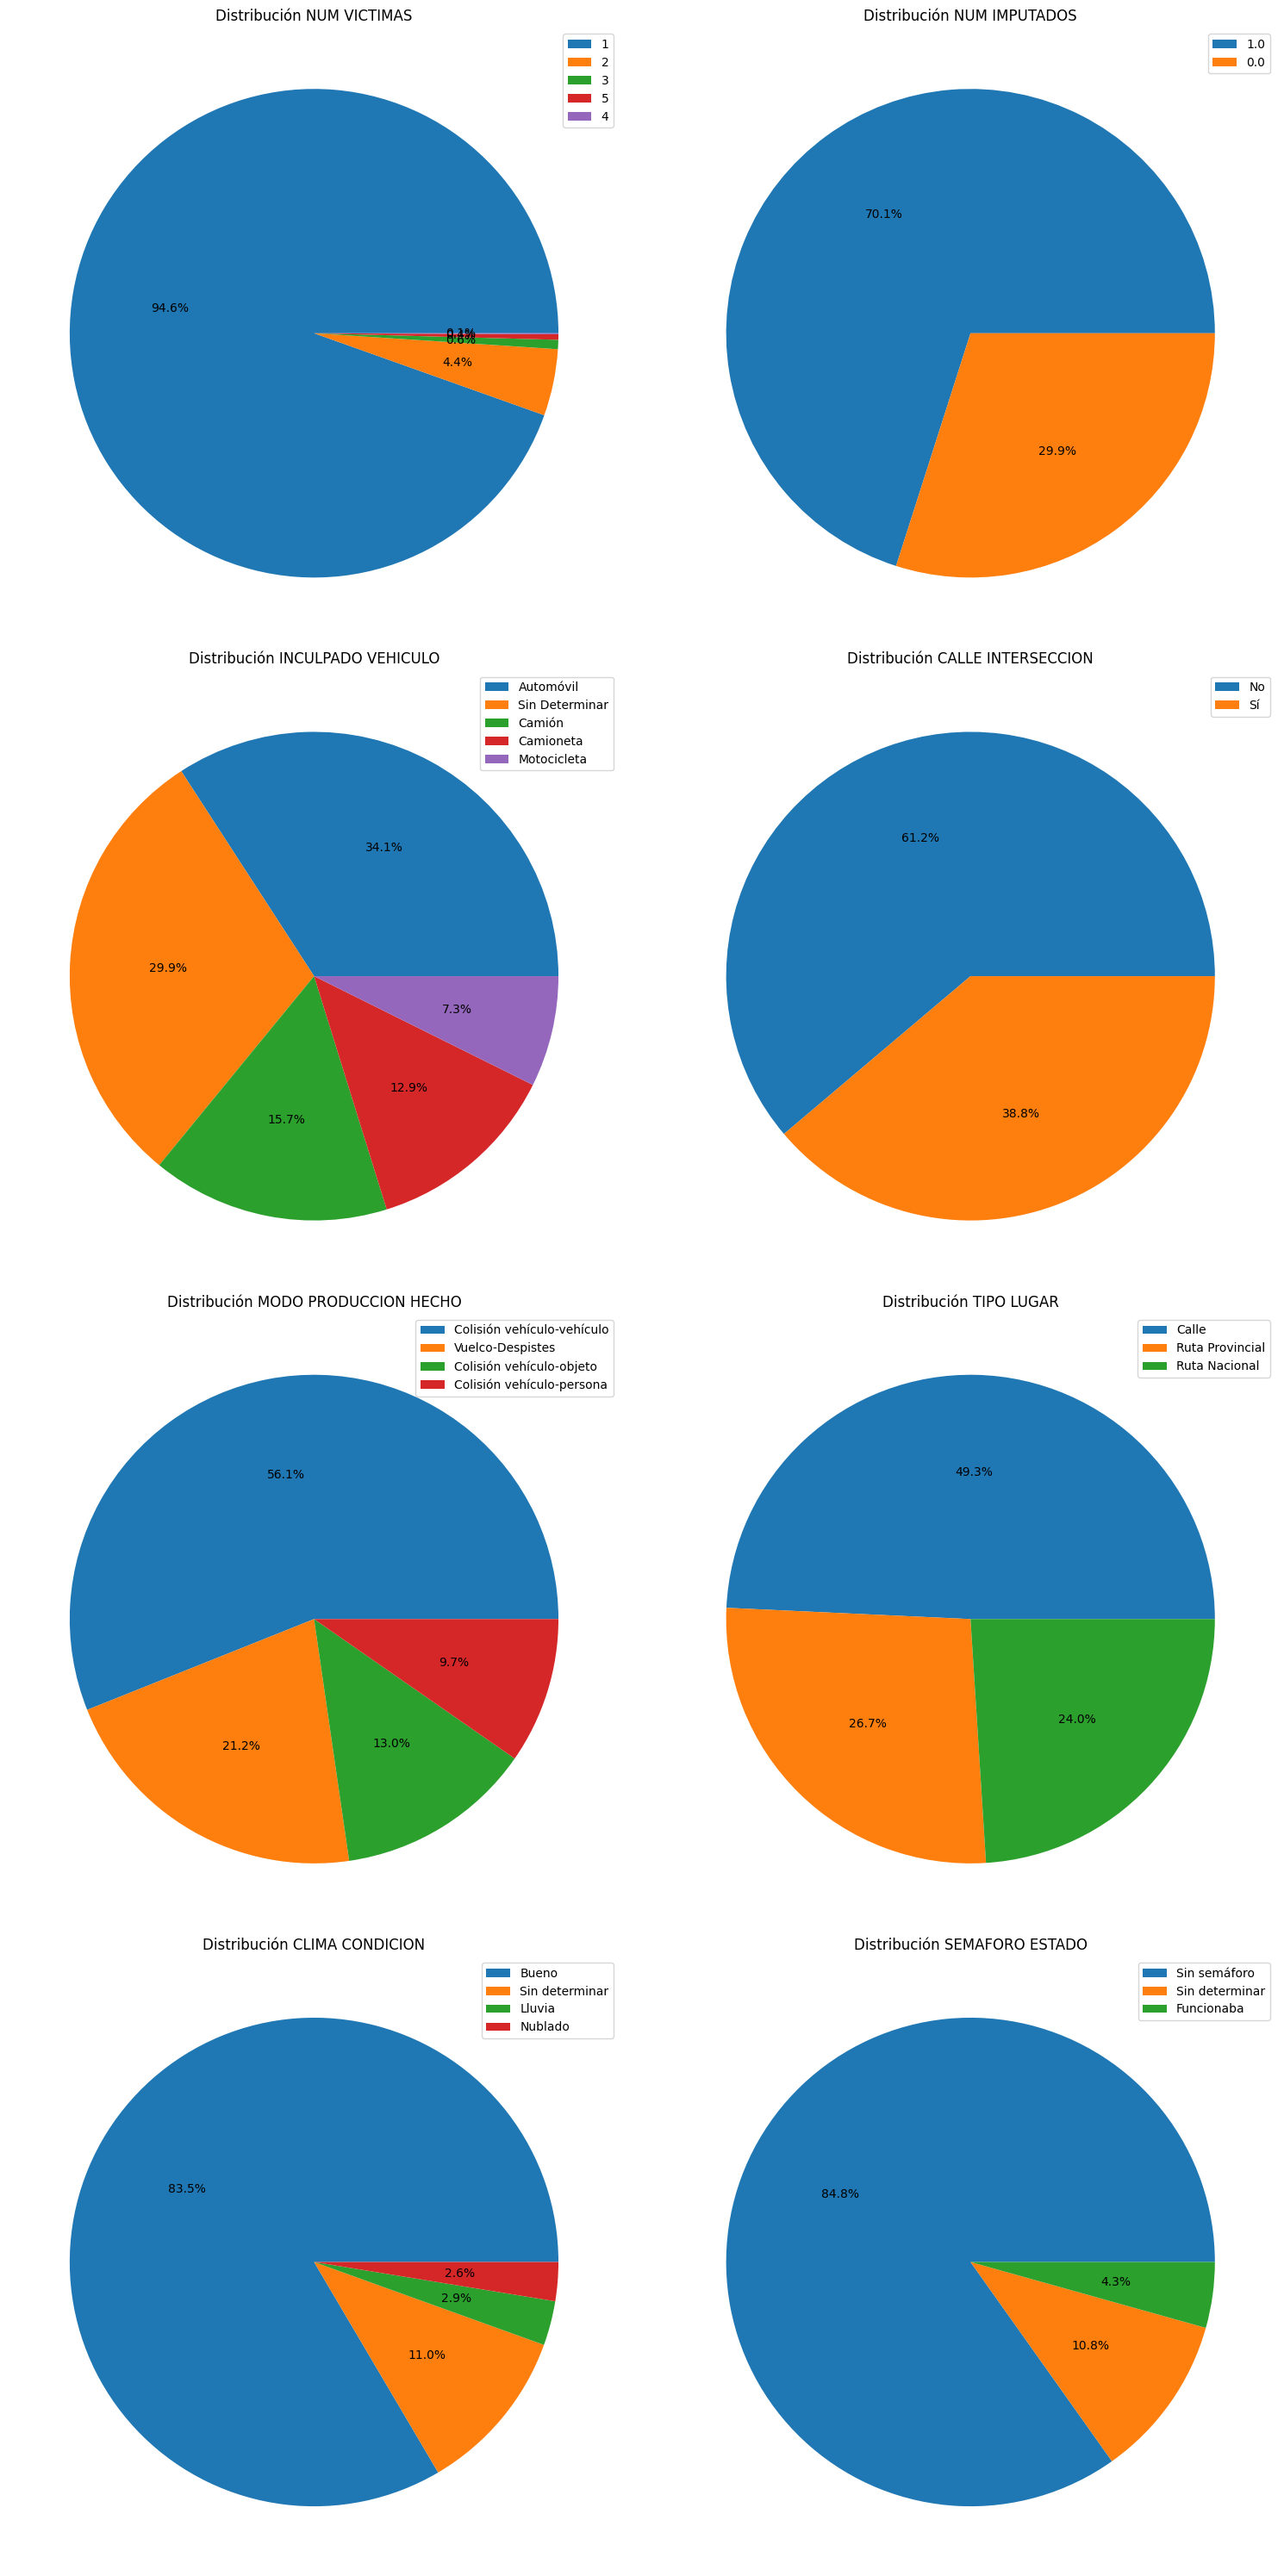

In [493]:
data = [
    {
        "name": "mes",
        "labels": [
            "Enero",
            "Febrero",
            "Marzo",
            "Abril",
            "Mayo",
            "Junio",
            "Julio",
            "Agosto",
            "Septiembre",
            "Octubre",
            "Noviembre",
            "Diciembre",
        ],
    },
    {"name": "semaforo_estado"},
    {"name": "clima_condicion"},
    {"name": "tipo_lugar"},
    {"name": "modo_produccion_hecho"},
    {"name": "calle_interseccion"},
    {"name": "inculpado_vehiculo"},
    {"name": "num_imputados"},
    {"name": "num_victimas"},
]

mostrarGraficos(accidente_vars, data, 4, 2, (16,30))

In [494]:
# Lista de atributos categóricos
atributos_categoricos = [
    "mes",
    "semaforo_estado",
    "clima_condicion",
    "tipo_lugar",
    "modo_produccion_hecho",
    "calle_interseccion",
    "inculpado_vehiculo",
    "num_imputados",
    "num_victimas"
]

# Crear tablas de frecuencia y porcentajes para cada atributo
for atributo in atributos_categoricos:
    print(f"Tabla de porcentajes para: {obtenerTituloColumna(atributo)}")
    # Columna de frecuencia
    frecuencia = accidente_vars[atributo].value_counts()
    # Columna de porcentaje
    porcentaje = round((frecuencia / len(accidente_vars)) * 100, 2)

    # Crear un DataFrame para visualizar mejor
    tabla = pd.DataFrame({"Frecuencia": frecuencia, "Porcentaje (%)": porcentaje})

    print(tabla)
    print("\n" + "-" * 50 + "\n")

Tabla de porcentajes para: MES
     Frecuencia  Porcentaje (%)
mes                            
8           165           10.10
3           162            9.91
12          143            8.75
10          142            8.69
1           139            8.51
11          138            8.45
9           132            8.08
5           128            7.83
2           127            7.77
4           126            7.71
6           126            7.71
7           106            6.49

--------------------------------------------------

Tabla de porcentajes para: SEMAFORO ESTADO
                 Frecuencia  Porcentaje (%)
semaforo_estado                            
Sin semáforo           1386           84.82
Sin determinar          177           10.83
Funcionaba               71            4.35

--------------------------------------------------

Tabla de porcentajes para: CLIMA CONDICION
                 Frecuencia  Porcentaje (%)
clima_condicion                            
Bueno                

In [495]:
print(
    accidente_vars.head(), accidente_vars[(accidente_vars["num_imputados"] == 0)]["id_hecho"]
)

   id_hecho  mes calle_interseccion semaforo_estado     tipo_lugar  \
0     17318    4                 No    Sin semáforo  Ruta Nacional   
1     17375    5                 No    Sin semáforo  Ruta Nacional   
2     17376    5                 No    Sin semáforo  Ruta Nacional   
3     17503    8                 No    Sin semáforo  Ruta Nacional   
4     17533    9                 No    Sin semáforo  Ruta Nacional   

        modo_produccion_hecho clima_condicion   estacion  es_finde horario  \
0  Colisión vehículo-vehículo           Bueno      Otoño     False  mañana   
1            Vuelco-Despistes           Bueno      Otoño      True  mañana   
2   Colisión vehículo-persona         Nublado      Otoño     False  mañana   
3  Colisión vehículo-vehículo           Bueno   Invierno     False   tarde   
4  Colisión vehículo-vehículo           Bueno  Primavera      True  mañana   

  inculpado_vehiculo  num_imputados  num_victimas  total_involucrados  
0             Camión            1.0   